# Credit Card Fraud Detection – Task 1: Data Understanding & Cleaning

In this section, we will:

- Load the credit card transactions dataset

- Explore its structure, data types, and missing values

- Perform basic cleaning (e.g., handling missing values, duplicates)


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Display versions (optional, helpful for reproducibility)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


pandas: 2.2.2
numpy: 2.3.3


In [3]:
# Load the credit card fraud dataset
# Adjust the path if needed based on your project structure
csv_path = "../Data//train.csv"

# Read the CSV file
try:
    df = pd.read_csv(csv_path)
    print("Dataset successfully loaded.")
except FileNotFoundError:
    raise FileNotFoundError(f"Could not find file at {csv_path}. Check the path.")

# Basic shape and preview
print("\nDataset shape (rows, columns):", df.shape)
print("\nFirst 5 rows:")
display(df.head())


Dataset successfully loaded.

Dataset shape (rows, columns): (1296675, 23)

First 5 rows:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
# Explore dataset structure, data types, and basic statistics

print("DataFrame info:\n")
df.info()

print("\nBasic statistics for numerical features:\n")
display(df.describe().T)

print("\nNumber of missing values per column:\n")
missing_counts = df.isnull().sum()
display(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else missing_counts)


DataFrame info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  l

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1296675.0,6.483370e+05,3.743180e+05,0.000000e+00,3.241685e+05,6.483370e+05,9.725055e+05,1.296674e+06
cc_num,1296675.0,4.171920e+17,1.308806e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01



Number of missing values per column:



Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [5]:
# Basic data cleaning: check and remove duplicates (if any)

# Count duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Remove duplicates if present
if num_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
    print("New dataset shape:", df.shape)
else:
    print("No duplicate rows found.")

# Confirm there are still no missing values after cleaning
print("\nMissing values after cleaning (should be all zeros if none):")
display(df.isnull().sum())


Number of duplicate rows: 0
No duplicate rows found.

Missing values after cleaning (should be all zeros if none):


Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

### Column Descriptions (Data Dictionary)

- **Unnamed: 0:** Row index.
- **trans_date_trans_time:** Date and time of the transaction.
- **cc_num:** Credit card number of the customer.
- **merchant:** Name of the merchant.
- **category:** Transaction category (e.g., personal care, grocery).
- **amt:** Amount of the transaction.
- **first:** First name of the credit card holder.
- **last:** Last name of the credit card holder.
- **gender:** Gender of the credit card holder.
- **street:** Street address of the credit card holder.
- **city:** City of the credit card holder.
- **state:** State of the credit card holder.
- **zip:** ZIP code of the credit card holder.
- **lat:** Latitude of the credit card holder's location.
- **long:** Longitude of the credit card holder's location.
- **city_pop:** Population of the credit card holder's city.
- **job:** Job title of the credit card holder.
- **dob:** Date of birth of the credit card holder.
- **trans_num:** Unique transaction identifier.
- **unix_time:** Transaction time in Unix epoch format.
- **merch_lat:** Latitude of the merchant's location.
- **merch_long:** Longitude of the merchant's location.
- **is_fraud:** Target variable (1 = Fraudulent transaction, 0 = Legitimate transaction).


## 2. Exploratory Data Analysis (EDA)

In this section, we will:
- Perform univariate & bivariate analysis
- Identify fraud patterns and key insights
- Visualize important trends


E:\Temp\ipykernel_28624\3474259557.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='is_fraud', data=eda_df, palette='viridis')


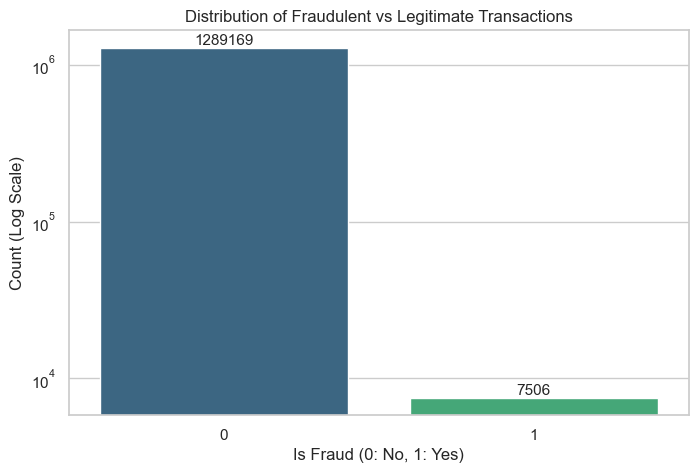

In [6]:
# Create a copy of the dataframe for EDA to leave the original untouched
eda_df = df.copy()

# Feature Engineering for Time/Date analysis
eda_df['trans_date_trans_time'] = pd.to_datetime(eda_df['trans_date_trans_time'])
eda_df['hour'] = eda_df['trans_date_trans_time'].dt.hour
eda_df['day_of_week'] = eda_df['trans_date_trans_time'].dt.day_name()

# 1. Target Variable Distribution (Univariate Analysis)
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='is_fraud', data=eda_df, palette='viridis')
plt.title('Distribution of Fraudulent vs Legitimate Transactions')
plt.yscale('log') # Log scale because of extreme class imbalance
plt.ylabel('Count (Log Scale)')
plt.xlabel('Is Fraud (0: No, 1: Yes)')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=11)
plt.show()


E:\Temp\ipykernel_28624\582276979.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amt', data=eda_df, palette='Set2')


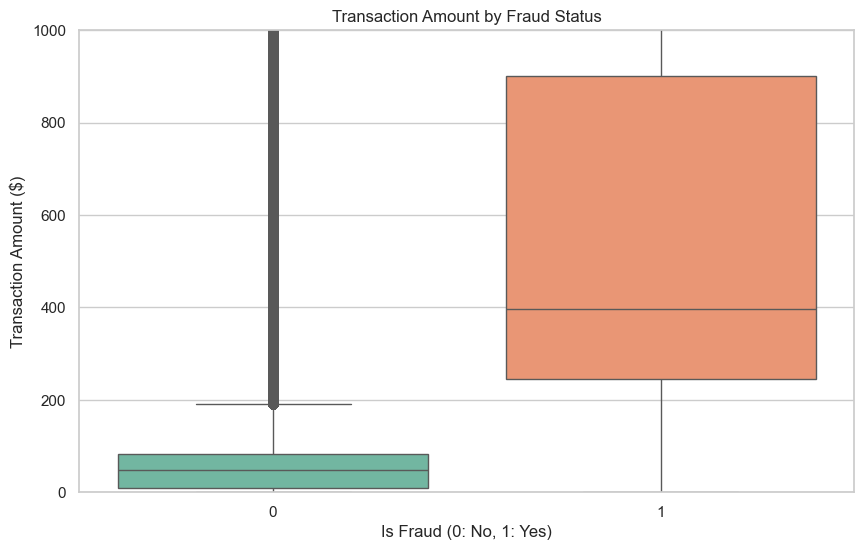

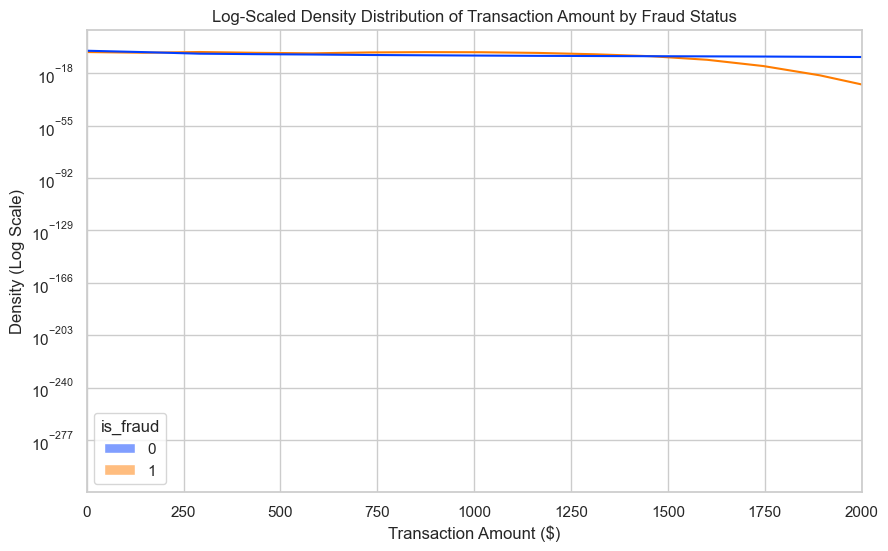

In [7]:
# 2. Transaction Amount vs Fraud (Bivariate Analysis)

# Boxplot for amount by fraud status
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amt', data=eda_df, palette='Set2')
plt.title('Transaction Amount by Fraud Status')
plt.ylim(0, 1000) # Limiting y-axis up to 1000 to better visualize the box plots
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Transaction Amount ($)')
plt.show()

# Density distribution of Transaction Amount by Fraud status
plt.figure(figsize=(10, 6))
sns.histplot(data=eda_df, x='amt', hue='is_fraud', bins=50, log_scale=(False, True), common_norm=False, kde=True, palette='bright', stat='density')
plt.title('Log-Scaled Density Distribution of Transaction Amount by Fraud Status')
plt.xlim(0, 2000)
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Density (Log Scale)')
plt.show()


E:\Temp\ipykernel_28624\73136484.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=fraud_by_category.index, x=fraud_by_category.values, palette='Reds_r')


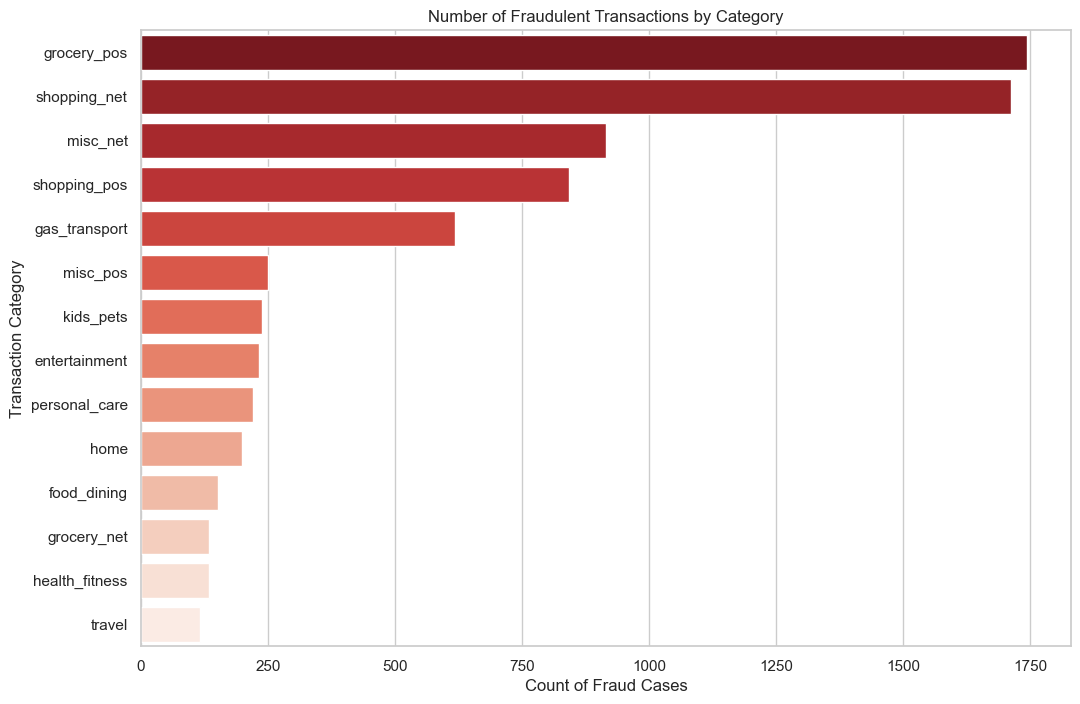

In [8]:
# 3. Fraud by Category (Bivariate Analysis)

plt.figure(figsize=(12, 8))
fraud_by_category = eda_df[eda_df['is_fraud'] == 1]['category'].value_counts().sort_values(ascending=False)
sns.barplot(y=fraud_by_category.index, x=fraud_by_category.values, palette='Reds_r')
plt.title('Number of Fraudulent Transactions by Category')
plt.xlabel('Count of Fraud Cases')
plt.ylabel('Transaction Category')
plt.show()


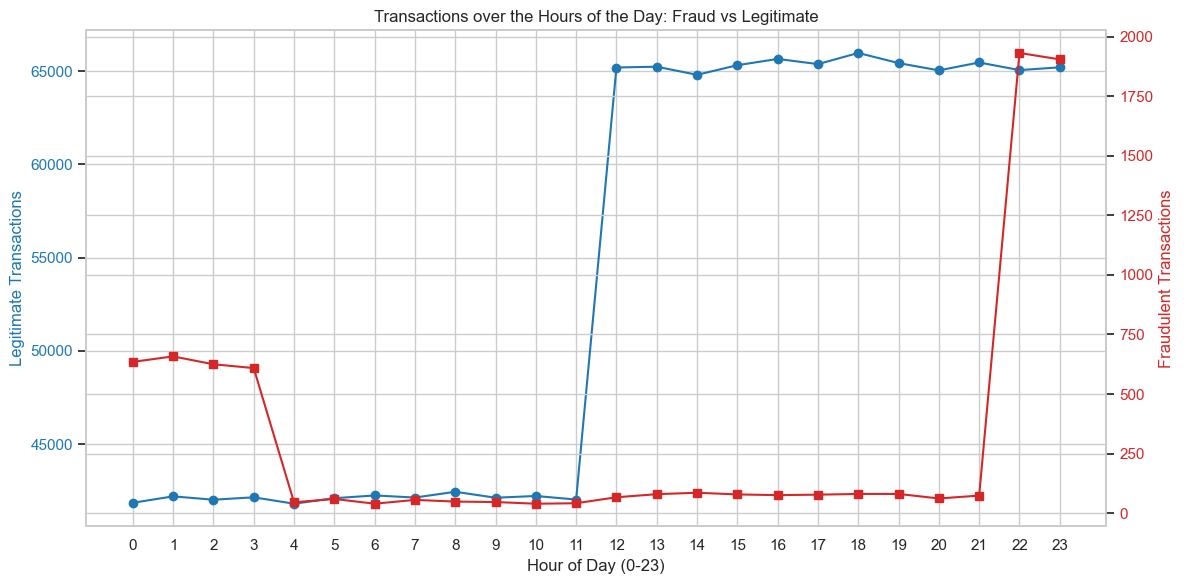

In [9]:
# 4. Fraud Trends over Time (Bivariate Analysis)

fraud_hourly = eda_df[eda_df['is_fraud'] == 1].groupby('hour').size()
legit_hourly = eda_df[eda_df['is_fraud'] == 0].groupby('hour').size()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot legitimate transactions on the left y-axis
ax1.set_xlabel('Hour of Day (0-23)')
ax1.set_ylabel('Legitimate Transactions', color='tab:blue')
ax1.plot(legit_hourly.index, legit_hourly.values, color='tab:blue', marker='o', label='Legitimate')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
# Plot fraudulent transactions on the right y-axis
ax2.set_ylabel('Fraudulent Transactions', color='tab:red')
ax2.plot(fraud_hourly.index, fraud_hourly.values, color='tab:red', marker='s', label='Fraud')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Transactions over the Hours of the Day: Fraud vs Legitimate')
fig.tight_layout()
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


### 📌 Key Insights & Fraud Patterns:

1. **Class Imbalance**: There is an extreme class imbalance; legitimate transactions vastly outnumber fraudulent ones, which is typical for real-world anomaly detection domains. This dictates that robust evaluation metrics (like Precision-Recall AUC or F1-Score) are required instead of just simple accuracy during our modeling phase.

2. **Transaction Amount Patterns**: 
   - Fraudulent transactions typically have notably higher transaction amounts compared to legitimate transactions.
   - While normal purchases cluster heavily at lower amounts, fraud amounts have a more distinct, wider distribution.

3. **Vulnerable Categories**:
   - Categories such as `grocery_pos` and `shopping_net` are disproportionately affected by fraud.
   - This suggests fraudsters predominantly target point-of-sale retail networks and online shopping spaces.

4. **Time-based Vulnerabilities**:
   - Fraudulent activity often peaks distinctively during late night and early morning hours (typically when legitimate transaction volume is lowest). 
   - Time-of-day forms a crucial discriminative feature for our prediction models.


In [10]:
def EDA(num_cols, cat_cols, df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import math
    import itertools
    
    if cat_cols:
        n_cols = 2  # Number of subplots per row
        total = len(cat_cols)
        num_rows = math.ceil(total / n_cols)
    
        plt.figure(figsize=(n_cols * 5, num_rows * 4))
    
        for idx, col in enumerate(cat_cols):
            plt.subplot(num_rows, n_cols, idx + 1)
            sns.countplot(data=df, x=col, order=df[col].value_counts().index)
            plt.title(col)
            plt.xticks(rotation=45)
            plt.tight_layout()
    
        plt.show()    
    
        pairs = list(itertools.combinations(cat_cols, 2))
        total = len(pairs)
        n_cols = 2  # 2 plots per row
        num_rows = math.ceil(total / n_cols)
    
        plt.figure(figsize=(n_cols * 6, num_rows * 5))
    
        for idx, (col1, col2) in enumerate(pairs):
            plt.subplot(num_rows, n_cols, idx + 1)
            sns.countplot(data=df, x=col1, hue=col2)
            plt.title(f"{col1} vs {col2}")
            plt.xticks(rotation=45)
            plt.tight_layout()
    
        plt.show()

    if num_cols:
        for col in num_cols:
            fig, axs = plt.subplots(1, 2, figsize=(12, 4))
            
            # Title for the whole row
            fig.suptitle(col, fontsize=14, fontweight='bold', y=1.05)
    
            # Histogram
            sns.histplot(df[col], kde=True, bins=30, ax=axs[0])
            axs[0].set_title('Histogram')
            axs[0].set_xlabel(col)
            axs[0].set_ylabel('Frequency')
    
            # Boxplot
            sns.boxplot(y=df[col], ax=axs[1])
            axs[1].set_title('Boxplot')
            axs[1].set_ylabel(col)
    
            plt.tight_layout()
            plt.show()

        
        pairs = list(itertools.combinations(num_cols, 2))
        total = len(pairs)
        n_cols = 2
        num_rows = math.ceil(total / n_cols)
    
        plt.figure(figsize=(n_cols * 6, num_rows * 5))
    
        for idx, (col1, col2) in enumerate(pairs):
            plt.subplot(num_rows, n_cols, idx + 1)
            sns.scatterplot(data=df, x=col1, y=col2)
            plt.title(f"{col1} vs {col2}")
            plt.tight_layout()
    
        plt.show()

        pairs = list(itertools.product(cat_cols, num_cols))

    if cat_cols and num_cols:
        for cat_col, num_col in pairs:
            plt.figure(figsize=(12, 5))
            
            # Title for this pair
            plt.suptitle(f'{num_col} vs {cat_col}', fontsize=14, fontweight='bold')
    
            # --- Left: Distribution plot (histogram per category) ---
            plt.subplot(1, 2, 1)
            sns.kdeplot(x=df[num_col], hue=df[cat_col],common_norm=False)
            plt.title(f'Distribution of {num_col} by {cat_col}')
    
            # --- Right: Barplot (mean of num_col per category) ---
            plt.subplot(1, 2, 2)
            sns.barplot(data=df, x=cat_col, y=num_col, estimator='mean', errorbar='sd')
            plt.title(f'Mean {num_col} by {cat_col}')
            plt.xticks(rotation=45)
    
            plt.tight_layout()
            plt.show()


In [11]:
# Change datatypes where necessary
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['zip'] = df['zip'].astype(str)
df['cc_num'] = df['cc_num'].astype(str)
df['is_fraud'] = df['is_fraud'].astype(str) # Converting target to categorical for EDA

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   cc_num             1296675 non-null  object 
 1   merchant           1296675 non-null  int16  
 2   category           1296675 non-null  int8   
 3   amt                1296675 non-null  float64
 4   gender             1296675 non-null  int8   
 5   city               1296675 non-null  int16  
 6   state              1296675 non-null  int8   
 7   zip                1296675 non-null  object 
 8   lat                1296675 non-null  float64
 9   long               1296675 non-null  float64
 10  city_pop           1296675 non-null  int64  
 11  job                1296675 non-null  int16  
 12  unix_time          1296675 non-null  int64  
 13  merch_lat          1296675 non-null  float64
 14  merch_long         1296675 non-null  float64
 15  is_fraud           1296675 non-n

In [12]:
import numpy as np
import pandas as pd
from math import radians, cos, sin, asin, sqrt

# --- Helper Function for Haversine Distance ---
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers
    return c * r

# 1. Time-Based Features
df['trans_date'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_hour'] = df['trans_date'].dt.hour
df['trans_day_of_week'] = df['trans_date'].dt.dayofweek
df['trans_month'] = df['trans_date'].dt.month
df['is_weekend'] = df['trans_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Distance-Based Features (Cardholder to Merchant)
df['distance_km'] = df.apply(
    lambda row: haversine(row['long'], row['lat'], row['merch_long'], row['merch_lat']), 
    axis=1
)

# 3. Demographic Features (Age)
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (df['trans_date'] - df['dob']).dt.days // 365

# Drop columns no longer needed for direct ML processing 
columns_to_drop = ['Unnamed: 0', 'trans_date_trans_time', 'trans_date', 'dob', 'trans_num', 'first', 'last', 'street']
df = df.drop(columns=columns_to_drop, errors='ignore')

# 4. Encoding Categorical Data (Required before Feature Selection)
cat_columns = ['merchant', 'category', 'gender', 'city', 'state', 'job']

# Using simple numerical encoding for this demonstration (Label or Target Encoding recommended in practice)
for col in cat_columns:
    df[col] = df[col].astype('category').cat.codes

df['is_fraud'] = df['is_fraud'].astype(int)


E:\Temp\ipykernel_28624\1601896928.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')


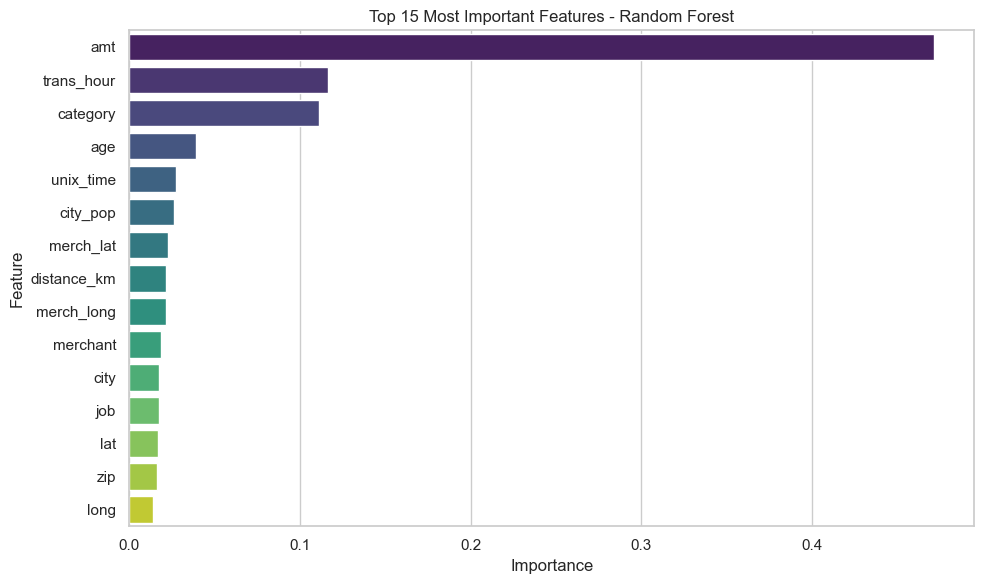

In [13]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

X = df.drop(columns=['is_fraud', 'cc_num']) 
y = df['is_fraud']

# Initialize model
rf_selector = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# Fit model for feature ranking on a subset of data (for speed due to 1.2M rows)
sample_df = df.sample(frac=0.1, random_state=42) 
X_sample = sample_df.drop(columns=['is_fraud', 'cc_num'])
y_sample = sample_df['is_fraud']

rf_selector.fit(X_sample, y_sample)

# Get feature importances
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features - Random Forest')
plt.tight_layout()
plt.show()

# Select only the top N features for final modeling
top_k_features = importances['Feature'].head(15).tolist()
X_final = X[top_k_features]


## Justification
### Feature Engineering:

Time-Based Features (Hour, Day, Weekend): Fraudsters consistently operate outside of standard banking/waking hours to avoid triggering real-time consumer alerts. Extracting trans_hour and predicting fraud spikes is crucial.
Haversine Distance: Card-not-present and physical retail frauds often happen far from the cardholder's home address. Since we have origin latitude/longitude and merchant latitude/longitude, extracting the exact spatial distance is one of the most predictive features you can add to this dataset.
Age Derivation: Senior citizens are mathematically proven to be targeted at different rates for fraud compared to young adults.
### Feature Selection (Random Forest Feature Importance):

Why RF? We have a massive mix of continuous features (like distance_km, city_pop) and categorical encodings (category, state). Standard selection methods like Pearson Correlation only measure linear relationships. Random Forests can naturally model highly non-linear dynamics and interactions between variables (e.g. Age + Shopping Net Category + 2:00 AM).
Speed & Scalability: Truncating your dataset and relying strictly on informational split criteria allows us to eliminate weak spatial features, dropping our data dimensionality significantly to prepare for advanced models (like XGBoost or SMOTE training).


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, f1_score, precision_recall_curve, auc, confusion_matrix

# Assuming 'X_final' holds our selected features and 'y' is our target 'is_fraud'
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

# We use RobustScaler because transaction amounts and distances can have extreme outliers
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Calculate class imbalance ratio for XGBoost/LightGBM
negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()
scale_pos_weight = negative_cases / positive_cases

print(f"Class Imbalance Ratio: {scale_pos_weight:.2f}")


Class Imbalance Ratio: 171.75


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. Logistic Regression (Baseline)
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# 2. Random Forest 
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# 3. XGBoost
xgb = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgb.fit(X_train_scaled, y_train)

# 4. LightGBM
lgb = LGBMClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
lgb.fit(X_train_scaled, y_train)


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\distributed\diagnostics\nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


[LightGBM] [Info] Number of positive: 6005, number of negative: 1031335
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.117468 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3170
[LightGBM] [Info] Number of data points in the train set: 1037340, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005789 -> initscore=-5.146017
[LightGBM] [Info] Start training from score -5.146017
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
models = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb, 'LightGBM': lgb}

# Dictionary to hold the PR-AUC scores
pr_auc_scores = {}

fig, ax = plt.subplots(figsize=(10, 7))

for name, model in models.items():
    # Predict probabilities for the positive class (Fraud)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)
    
    # Calculate Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    pr_auc = auc(recall, precision)
    pr_auc_scores[name] = pr_auc
    
    # Plot PR Curve
    ax.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.3f})')
    
    # Print F1 Score for a quick check
    print(f"--- {name} ---")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    # print(classification_report(y_test, y_pred)) # Uncomment to see full report

ax.set_xlabel('Recall (Detecting Fraud)')
ax.set_ylabel('Precision (Not Blocking Normal Users)')
ax.set_title('Precision-Recall Curve Comparison')
ax.legend(loc='lower left')
plt.show()

best_model_name = max(pr_auc_scores, key=pr_auc_scores.get)
print(f"\n=> The Best Model is {best_model_name} with a PR-AUC of {pr_auc_scores[best_model_name]:.3f}")


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Let's assume XGBoost won the comparison. If LightGBM won, adjust the parameter grid accordingly.
param_dist = {
    'learning_rate': uniform(0.01, 0.2), # Focus on lower learning rates
    'max_depth': randint(4, 10),         # Keep depth reasonable to prevent overfitting
    'min_child_weight': randint(1, 10),  # Controls over-fitting for imbalanced data
    'subsample': uniform(0.7, 0.3),      # Use fraction of rows per tree
    'colsample_bytree': uniform(0.7, 0.3) # Use fraction of cols per tree
}

# Use fewer rows (e.g., 20% of training data) for tuning to save hackathon time
X_tune, _, y_tune, _ = train_test_split(X_train_scaled, y_train, train_size=0.2, stratify=y_train, random_state=42)

xgb_tuner = XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=150, random_state=42, n_jobs=-1)

# Note: We use scoring='average_precision' which corresponds to PR-AUC
random_search = RandomizedSearchCV(
    estimator=xgb_tuner, 
    param_distributions=param_dist, 
    n_iter=15,          # Try 15 different parameter combinations
    scoring='average_precision', 
    cv=3,               # 3-fold cross-validation
    verbose=2, 
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_tune, y_tune)

print("Best Parameters found: ", random_search.best_params_)
print("Best PR-AUC Score in CV: ", random_search.best_score_)

# Train the final model with best parameters on the FULL training set
final_model = random_search.best_estimator_
final_model.fit(X_train_scaled, y_train)

# Final Evaluation
y_pred_final = final_model.predict(X_test_scaled)
print("\n=== Final Model Classification Report ===")
print(classification_report(y_test, y_pred_final))


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Define the Stratified K-Fold Strategy
# We use 3 splits or 5 splits. (5 is standard, but 3 is faster for a 1.2M row dataset during a hackathon)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 2. Define the exact metrics we want to track across the folds
scoring_metrics = {
    'pr_auc': 'average_precision', # Best metric for imbalanced data
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision',
    'roc_auc': 'roc_auc'
}

print(f"Starting {skf.get_n_splits()}-Fold Stratified Cross-Validation on final_model...")

# 3. Perform Cross-Validation on the training dataset
# Using n_jobs=-1 forces it to run on all available CPU cores parallelly
cv_results = cross_validate(
    estimator=final_model, 
    X=X_train_scaled, 
    y=y_train, 
    cv=skf, 
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=False # We only care about test/validation fold scores
)

# 4. Print the final results (Mean and Standard Deviation)
print("\n=== XGBoost Final Model Cross-Validation Results ===")

for metric in scoring_metrics.keys():
    # Extract the array of scores for the current metric across all folds
    test_scores = cv_results[f'test_{metric}']
    
    # Calculate Mean and Standard Deviation (low Std Dev means the model is highly stable!)
    mean_score = np.mean(test_scores)
    std_score = np.std(test_scores)
    
    print(f"{metric.upper()}: {mean_score:.4f} (+/- {std_score:.4f})")
    
print("====================================================")
